# Single Match Analysis - Final Match




## 0. Setup - Imports and Configuration

In [37]:

import numpy as np
import pandas as pd

import config
from src.analysis.game_utils import game_summary
from src.analysis.prediction_utils import normalize_predictions, get_top_indices, visualize_top_sequences
from src.data.data_loader import load_socceraction_match
from src.ml.models.model_factory import load_model
from src.ml.preprocessing.sequence_preprocessor import SequencePreprocessor, PreprocessingMode
from src.ml.preprocessing.xthreat import get_default_xt_model


In [38]:
# Configure pandas display options
pd.set_option('display.width', 1000)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

## 1. Load and Split Data

In [39]:
match_id = 3943043
selected_match, selected_events = load_socceraction_match("data/statsbomb/data", 55, 282, match_id)

print(f"Loaded match: {game_summary(selected_match)} with {len(selected_events)} events")

Found 51 matches in competition 55, season 282
Loading events for match 3942819 (1/51)...
Loading events for match 3943043 (2/51)...
Loaded match: Spain 2 : 1 England (Final) [14.07.2024] with 3312 events


## 2. Preprocess Data for Analysis

In [40]:
# Initialize preprocessor
preprocessor = SequencePreprocessor(
    sequence_length=config.SEQUENCE_LENGTH,
    minimum_sequence_length=config.MINIMUM_SEQUENCE_LENGTH,
    xt_model=get_default_xt_model()
)

# Process validation set for analysis
X, y, p = preprocessor.process_match(match_id, selected_match, selected_events, mode=PreprocessingMode.VALIDATION)
print(f"Validation set preprocessed: {X.shape[0]} sequences")


→Processing match 3943043: 3312 events (mode: validation)
 → Generated 124 sequences, 124 labels for match 3943043
Validation set preprocessed: 124 sequences


In [41]:
X.shape

(124, 8, 46)

## 3. Load Trained Model

In [42]:
# Load the best trained model
MODEL_TYPE = 'attention_lstm'  # Change to 'transformer' if using the transformer model
MODEL_DIR = 'generated/attention_lstm_attention_lstm_large_20260214_170158'

model = load_model(MODEL_TYPE, MODEL_DIR)
print(f"Model type: {MODEL_TYPE}")


Model type: attention_lstm


## 4. Analysis


#### Make predictions on match sequences

In [43]:
predictions = model.predict(X, batch_size=32, verbose=0)


#### Predictions

In [44]:
predicted_values, attention_weights = normalize_predictions(predictions)
print(f"Total sequences analyzed: {len(predicted_values)}")
print(f"Sum of all predicted values: {predicted_values.sum():.3f}")
print(f"Has attention weights: {attention_weights is not None}")

Total sequences analyzed: 124
Sum of all predicted values: 8.108
Has attention weights: True


#### IDS from highlights

In [45]:
possession_ids = [
    21,
    75,
    81,
    83,
    92,
    100,
    105,
    115,
    117,
    129,
    136,
    138,
]
indices = [i for i, df in enumerate(p) if df['possession'].iloc[0] in possession_ids]
indices

[16, 63, 67, 69, 78, 85, 90, 100, 101, 111, 118, 120]

#### Top possessions information

In [46]:
sorted_indices = get_top_indices(predicted_values)
sorted_indices

array([118, 119,   7, 106, 120,  51,  20, 116,  90,  94,  49,  24,  59,
       103,  67, 111,  63,  17,  30,  69,  18,  34, 107,  87, 100,  32,
        23,  96,  16,  64, 115,   8, 101,  21,  10,  38, 108,  78,  73,
        48,  82,  85, 105,   0,  95,  54,  92,  62,  57,  91, 123, 104,
        77,  68,  26,   2, 112,  43, 114, 121,  12,  39,  75,  58,  28,
        84,  56,  50,  83,  55,  46,  97,  42,  36,  14,  33,  80,  74,
       117,  72,  52,  89,   6,  99,  88,  37,  25, 110,   5,  15,  53,
        76,  86, 109,  70,  71,  98,   1,  19,  35,  29,   3,  45,  41,
       102, 122,  65,  13,   9,  61,  93,  79,  22,   4,  66,  40,  47,
       113,  31,  81,  60,  27,  11,  44])

#### Analyse highlights with model predictions

In [47]:
results = []
for pos_id in possession_ids:
    idx = next(i for i, df in enumerate(p) if df['possession'].iloc[0] == pos_id)
    rank = np.where(sorted_indices == idx)[0][0] + 1
    value = predicted_values[idx]
    results.append({
        'possession_id': pos_id,
        'rank': rank,
        'value': value,
        'top_20': rank <= 20
    })

df_results = pd.DataFrame(results)
df_results.to_csv(f'generated/{MODEL_TYPE}_highlights_results.csv')
df_results.style.hide(axis='index')

possession_id,rank,value,top_20
21,29,0.086625,False
75,17,0.169133,True
81,15,0.197944,True
83,20,0.151171,True
92,38,0.055189,False
100,42,0.047845,False
105,9,0.240448,True
115,25,0.107653,False
117,33,0.059601,False
129,16,0.182567,True


#### Analyse specific possession by index

In [48]:
# visualize_top_sequences(p, predicted_values, attention_weights, indices=np.array(indices), cols=4)
for idx in indices:
    print(f"Possession ID: {p[idx]['possession'].iloc[0]}")
    print(p[idx][['type_name', 'player_name', 'xG', 'xT']])
# None
# # plot_possession_actions(p[possession_id])
# # p[possession_id][['type_name', 'player_name', 'xG', 'xT']]

Possession ID: 21
    type_name                player_name       xG        xT
277      Pass      Daniel Carvajal Ramos  0.00000  0.016895
278      Pass                Kyle Walker  0.00000  0.014291
279     Carry      Marc Cucurella Saseta  0.00000  0.014291
280      Pass      Marc Cucurella Saseta  0.00000  0.014736
281     Carry           Fabián Ruiz Peña  0.00000  0.014736
282      Pass           Fabián Ruiz Peña  0.00000  0.027563
283     Carry  Nicholas Williams Arthuer  0.00000  0.064426
284      Shot  Nicholas Williams Arthuer  0.06803  0.064426
Possession ID: 75
     type_name            player_name        xG        xT
956       Pass            Declan Rice  0.000000  0.029533
957  Clearance  Daniel Carvajal Ramos  0.000000  0.257454
958       Shot             Phil Foden  0.179694  0.064426
Possession ID: 81
     type_name                  player_name        xG        xT
1002     Carry              Aymeric Laporte  0.000000  0.012626
1003      Pass              Aymeric Laporte  0

# 5. Wyresy

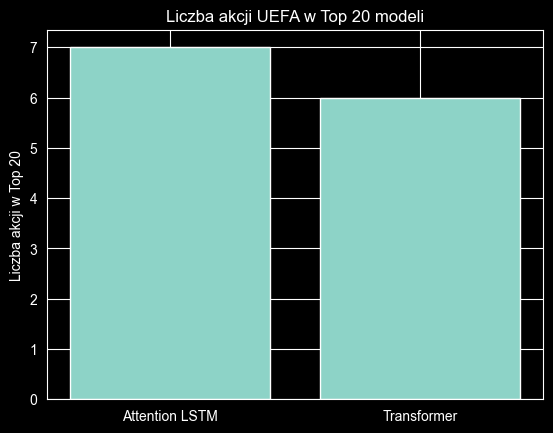

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

attention = pd.read_csv("generated/attention_lstm_highlights_results.csv")
transformer = pd.read_csv("generated/transformer_highlights_results.csv")

top20_counts = [
    attention["top_20"].sum(),
    transformer["top_20"].sum()
]

plt.figure()
plt.bar(["Attention LSTM", "Transformer"], top20_counts)
plt.ylabel("Liczba akcji w Top 20")
plt.title("Liczba akcji UEFA w Top 20 modeli")
plt.show()

/var/folders/vd/ld_f127d3sb255vmfwhgmc140000gn/T/ipykernel_52844/843159100.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


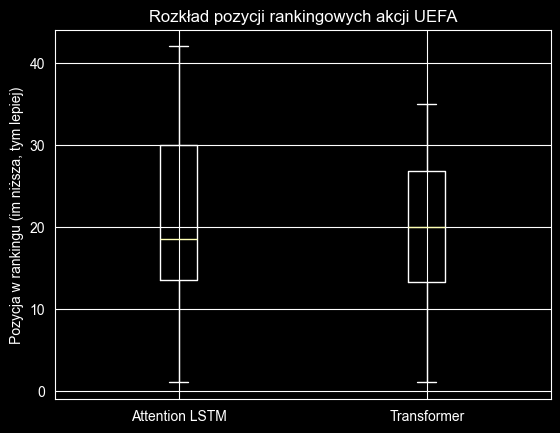

In [50]:
plt.figure()
plt.boxplot(
    [attention["rank"], transformer["rank"]],
    labels=["Attention LSTM", "Transformer"]
)
plt.ylabel("Pozycja w rankingu (im niższa, tym lepiej)")
plt.title("Rozkład pozycji rankingowych akcji UEFA")
plt.show()

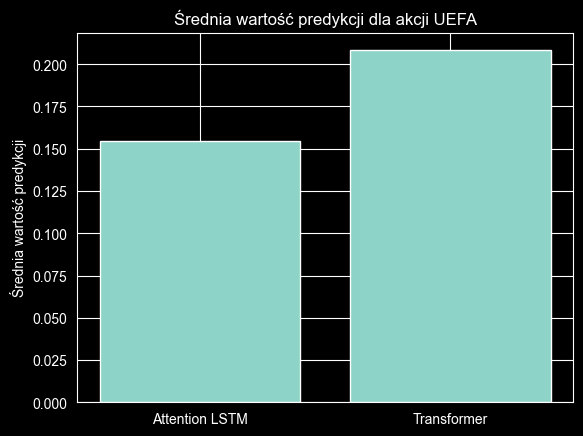

In [51]:
mean_values = [
    attention["value"].mean(),
    transformer["value"].mean()
]

plt.figure()
plt.bar(["Attention LSTM", "Transformer"], mean_values)
plt.ylabel("Średnia wartość predykcji")
plt.title("Średnia wartość predykcji dla akcji UEFA")
plt.show()

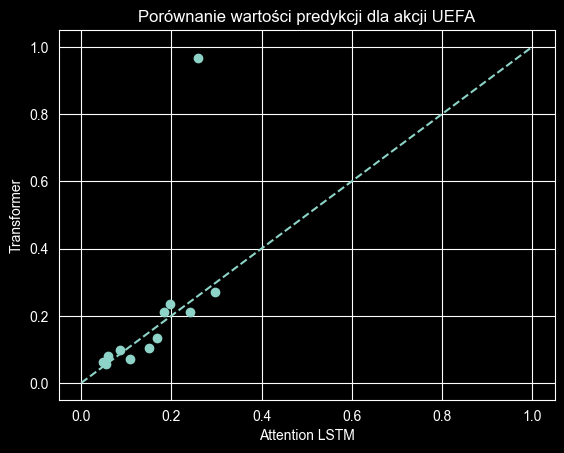

In [52]:
plt.figure()
plt.scatter(attention["value"], transformer["value"])
plt.xlabel("Attention LSTM")
plt.ylabel("Transformer")
plt.title("Porównanie wartości predykcji dla akcji UEFA")
plt.plot([0, 1], [0, 1], linestyle="--")  # linia idealnej zgodności
plt.show()

In [53]:
comparison_df = pd.DataFrame({
    'possession_id': attention['possession_id'],
    'Transformer - value': transformer['value'],
    'Transformer - position': transformer['rank'],
    'Transformer - top_20': transformer['top_20'],
    'Attention LSTM - value': attention['value'],
    'Attention LSTM - position': attention['rank'],
    'Attention LSTM - top_20': attention['top_20'],
})
comparison_df.style.hide(axis='index')

possession_id,Transformer - value,Transformer - position,Transformer - top_20,Attention LSTM - value,Attention LSTM - position,Attention LSTM - top_20
21,0.097592,23,False,0.086625,29,False
75,0.134485,18,True,0.169133,17,True
81,0.235049,11,True,0.197944,15,True
83,0.102585,22,False,0.151171,20,True
92,0.055674,35,False,0.055189,38,False
100,0.062063,33,False,0.047845,42,False
105,0.212409,15,True,0.240448,9,True
115,0.070732,29,False,0.107653,25,False
117,0.080791,26,False,0.059601,33,False
129,0.212565,14,True,0.182567,16,True


In [59]:
negative = attention[attention['top_20'] == False]
negative_ids = negative['possession_id'].tolist()
negative_ids

[21, 92, 100, 115, 117]

Processed sequence index: 16 with predicted value: 0.087
Processed sequence index: 78 with predicted value: 0.055
Processed sequence index: 85 with predicted value: 0.048
Processed sequence index: 100 with predicted value: 0.108
Processed sequence index: 101 with predicted value: 0.060


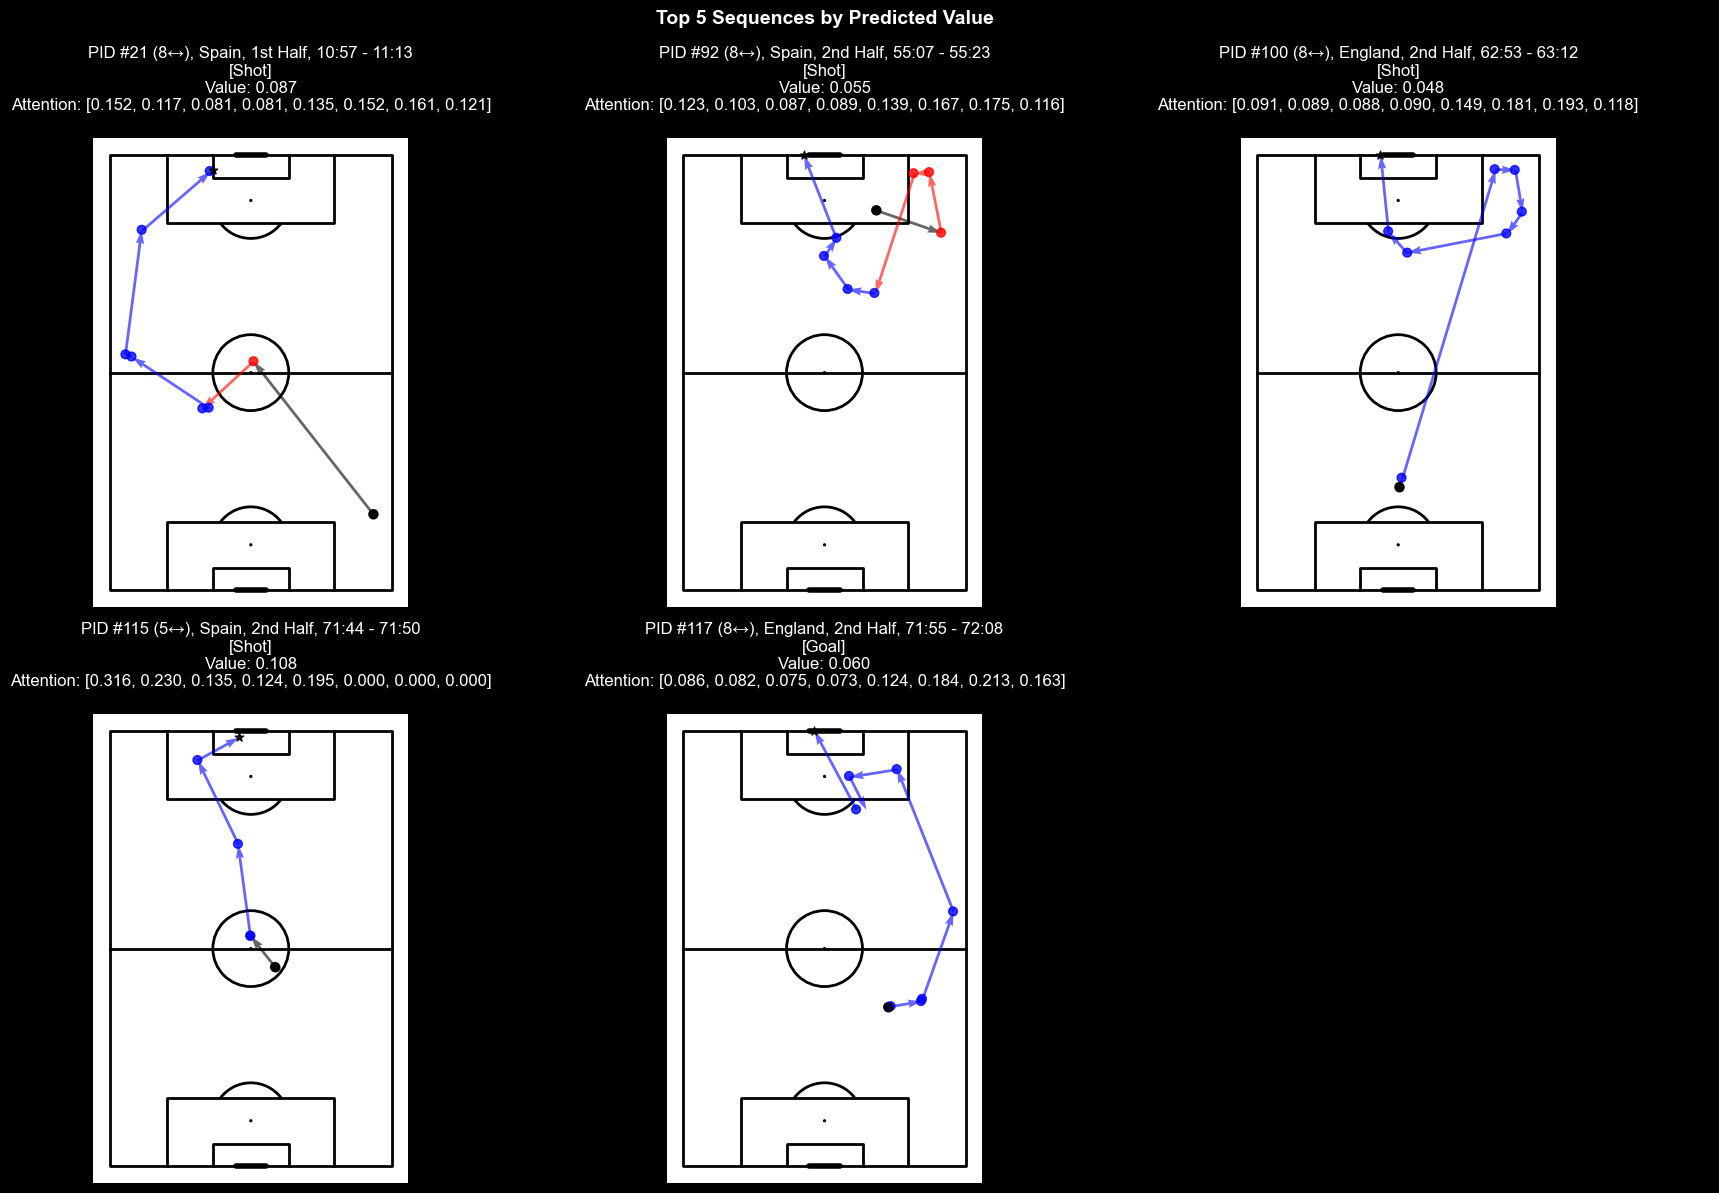

In [65]:
indices = [i for i, df in enumerate(p) if df['possession'].iloc[0] in negative_ids]
visualize_top_sequences(p, predicted_values, attention_weights, indices=np.array(indices), cols=3)
plt.savefig('generated/negative_highlights.png')